**Importing the libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Loading the data and getting an overview**

In [ ]:
raw_data = pd.read_csv("rating.csv")

In [ ]:
raw_data.head(5)

,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39
3,1,47,3.5,2005-04-02 23:32:07
4,1,50,3.5,2005-04-02 23:29:40


**Cleaning and Formatting the data** <br>
Checking if the data types are in proper order or if there's any missing data.

In [ ]:
raw_data['timestamp'] = raw_data['timestamp'].astype(str).str.rstrip(':')
raw_data['timestamp'] = pd.to_datetime(raw_data['timestamp'], format='mixed', errors='coerce')

In [ ]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 697285 entries, 0 to 697284
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   userId     697285 non-null  int64         
 1   movieId    697285 non-null  int64         
 2   rating     697285 non-null  float64       
 3   timestamp  697284 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 21.3 MB


In [ ]:
raw_data.describe(include="all")

,userId,movieId,rating,timestamp
count,697285.000000,697285.000000,697285.000000,697284
mean,2357.968122,8810.348486,3.518017,2004-10-13 21:05:56.246222720
min,1.000000,1.000000,0.500000,1996-03-15 22:16:09
25%,1183.000000,904.000000,3.000000,2000-08-07 20:55:35.250000
50%,2352.000000,2161.000000,3.500000,2004-11-22 16:50:09
75%,3532.000000,4719.000000,4.000000,2008-08-03 22:19:10.249999872
max,4618.000000,130642.000000,5.000000,2015-03-31 01:10:40
std,1338.307363,19352.203802,1.055049,NaN


Dropping the duplicates

In [ ]:
raw_data.drop_duplicates(inplace=True)
raw_data.dropna(inplace=True)

In [ ]:
raw_data.isnull().sum()

,0
userId,0
movieId,0
rating,0
timestamp,0


In [ ]:
raw_data.nunique()

,0
userId,4618
movieId,13378
rating,10
timestamp,548216


In [ ]:
raw_data.groupby("userId")["movieId"].count().sort_values(ascending=False).describe()

,movieId
count,4618.000000
mean,150.992638
std,230.409782
min,20.000000
25%,35.000000
50%,70.000000
75%,164.750000
max,2711.000000


**Feature Engineering**

1. In order to preserve the recency of data, we only operate on the data from the latest 3 years. We drop everything prior to that.

In [ ]:
raw_data = raw_data[raw_data['timestamp'] >= '2013-04-01']
raw_data.shape

(40635, 4)

In [ ]:
raw_data.describe(include="all")

,userId,movieId,rating,timestamp
count,40635.000000,40635.000000,40635.000000,40635
mean,2310.577064,34968.924105,3.579623,2014-05-22 17:22:50.574455552
min,31.000000,1.000000,0.500000,2013-04-01 01:45:35
25%,1108.000000,2057.500000,3.000000,2013-11-10 22:56:40.500000
50%,2301.000000,6662.000000,4.000000,2014-06-16 00:13:38
75%,3387.000000,71535.000000,4.500000,2014-12-29 20:01:55
max,4605.000000,130642.000000,5.000000,2015-03-31 01:10:40
std,1343.497345,40079.348973,1.061407,NaN


2. Deriving meaningful features to work on from the main raw data by appropriate feature engineering.

In [ ]:
user_features = (raw_data.groupby("userId").agg(

    num_interactions=("movieId", "count"),
        active_days=("timestamp", lambda x: x.dt.date.nunique()),
        first_interaction=("timestamp", "min"),
        last_interaction=("timestamp", "max")
    )
    .reset_index()
)

reference_date = raw_data["timestamp"].max()


user_features["recency_days"] = (
   reference_date - user_features["last_interaction"]
).dt.days

user_features["span_days"] = (
    user_features["last_interaction"] - user_features["first_interaction"]
).dt.days

user_features = user_features.drop(
    columns=["first_interaction", "last_interaction"]
)

user_features.head(5)

,userId,num_interactions,active_days,recency_days,span_days
0,31,246,3,33,1
1,42,51,1,186,0
2,49,30,1,696,0
3,59,25,1,548,0
4,71,45,1,119,0


3. Plotting the distribution of new data

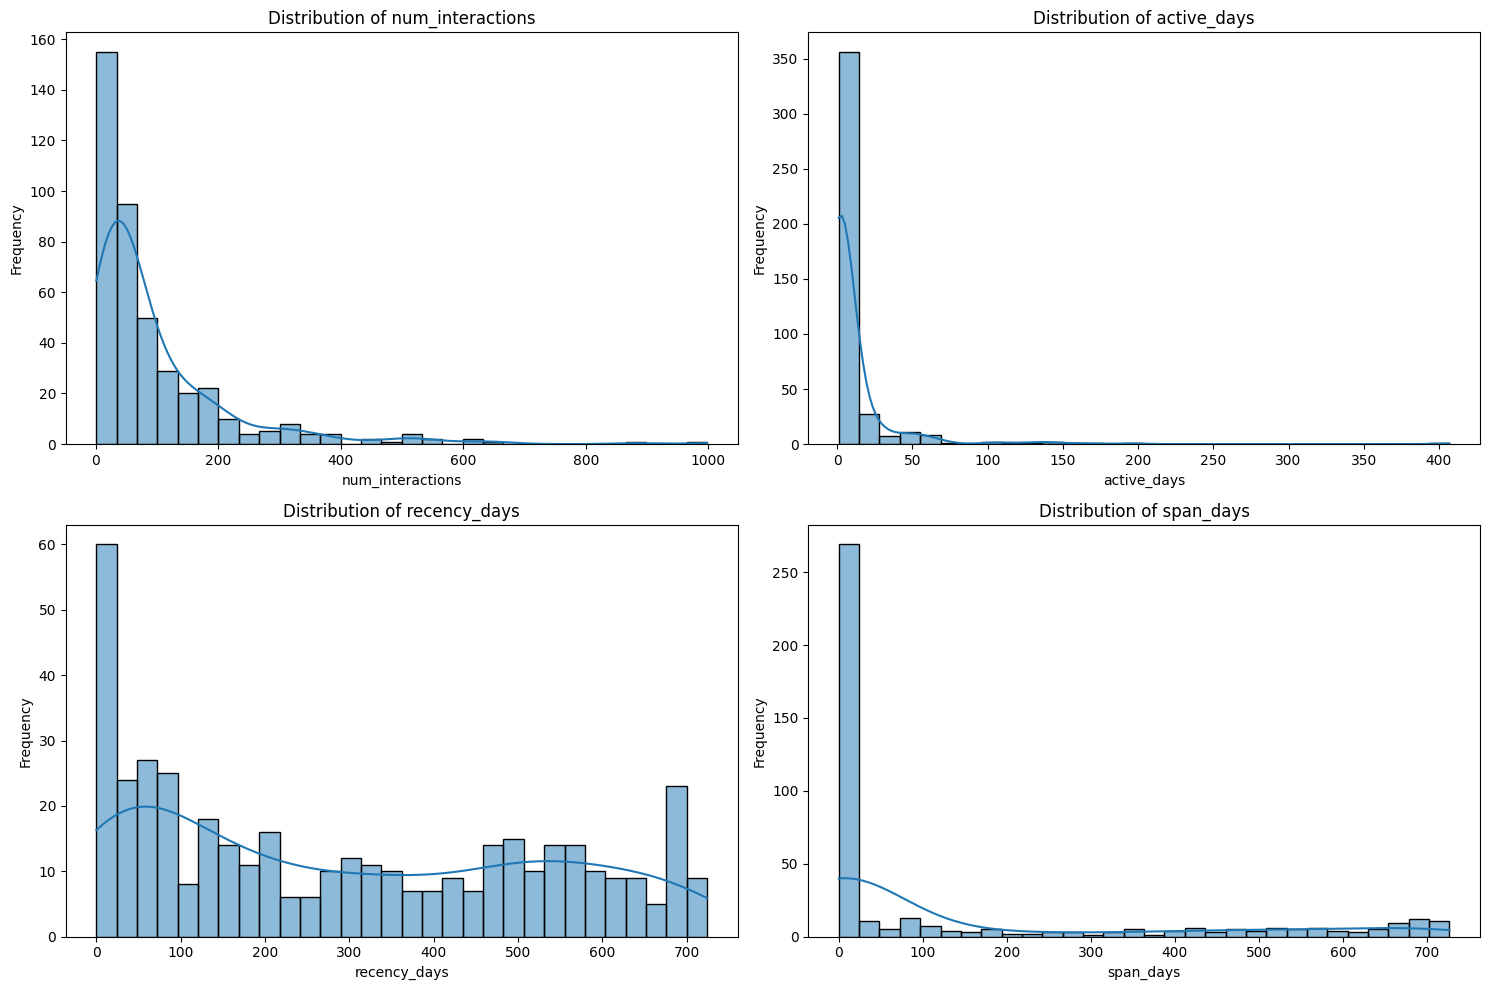

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

features_to_plot = ['num_interactions', 'active_days', 'recency_days', 'span_days']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(features_to_plot):
    plt.subplot(2, 2, i + 1) # Arrange in a 2x2 grid
    sns.histplot(user_features[feature], kde=True, bins=30)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

It's heavily skewed, so we apply scaling and log transformation!

In [ ]:
from sklearn.preprocessing import StandardScaler

features = user_features.copy()
features["log_num_interactions"] = np.log1p(features["num_interactions"])
features["log_active_days"] = np.log1p(features["active_days"])
features["log_span_days"] = np.log1p(features["span_days"])

X = features[
    ["log_num_interactions", "log_active_days", "recency_days", "log_span_days"]
]

scaler = StandardScaler()
X_transformed = scaler.fit_transform(X)

X_transformed = pd.DataFrame(
    X_transformed,
    columns=X.columns,
    index=features["userId"]
)

X_transformed.head(5)

,log_num_interactions,log_active_days,recency_days,log_span_days
userId,,,,
31,1.268375,-0.069107,-1.098226,-0.558237
42,0.019945,-0.692649,-0.445265,-0.814501
49,-0.394496,-0.692649,1.731270,-0.814501
59,-0.535425,-0.692649,1.099648,-0.814501
71,-0.078288,-0.692649,-0.731202,-0.814501


In [ ]:
X_transformed.shape

(420, 4)

In [ ]:
X_transformed.describe()

,log_num_interactions,log_active_days,recency_days,log_span_days
count,4.200000e+02,4.200000e+02,4.200000e+02,4.200000e+02
mean,-1.670621e-16,2.157005e-16,7.612958e-17,3.912214e-17
std,1.001193e+00,1.001193e+00,1.001193e+00,1.001193e+00
min,-2.590536e+00,-6.926490e-01,-1.239060e+00,-8.145005e-01
25%,-5.354249e-01,-6.926490e-01,-9.499224e-01,-8.145005e-01
50%,1.994455e-02,-5.102745e-01,-2.020052e-01,-8.145005e-01
75%,6.832656e-01,2.956425e-01,9.161364e-01,1.121451e+00
max,2.387985e+00,4.091434e+00,1.850766e+00,1.622002e+00


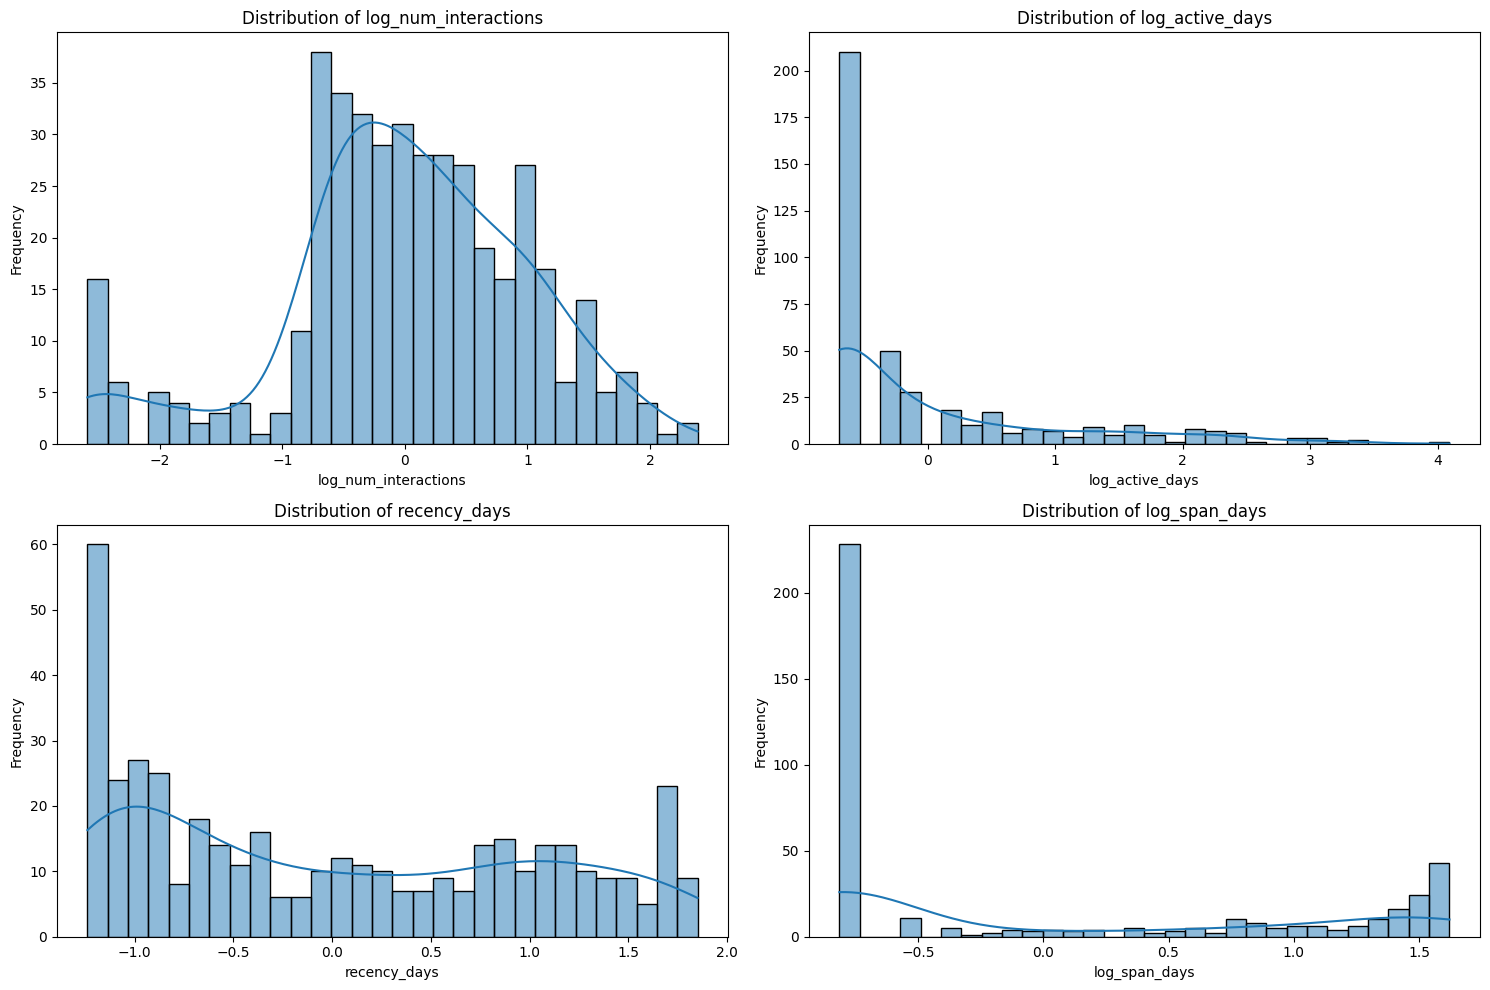

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Update features_to_plot to match the columns in X_transformed
features_to_plot = ['log_num_interactions', 'log_active_days', 'recency_days', 'log_span_days']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(features_to_plot):
    plt.subplot(2, 2, i + 1) # Arrange in a 2x2 grid
    sns.histplot(X_transformed[feature], kde=True, bins=30)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Determining the Suitable number of Clusters**

1. Firstly we calculate the Inertia score for each possibility. It gives us an estimate of how the cluster points are distributed with respect to the distance from the centrioid. In vauge terms it defines the tightness of the cluster. Although the more clusters we use the tightness with increase linearly and thus this can't be a sole metric for finalizing number of clusters. But it does provide important intution.

In [ ]:
from sklearn.cluster import KMeans

inertias = {}
cluster_sizes = {}

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X_transformed)

    inertias[k] = kmeans.inertia_
    sizes = pd.Series(labels).value_counts().sort_index()
    cluster_sizes[k] = sizes

inertias

{2: 869.0292761433963,
 3: 635.854550700759,
 4: 513.4232518828503,
 5: 399.85058694144595,
 6: 352.918073195144,
 7: 311.38393052748785,
 8: 278.0160709985842}

2. We calculate the Silhouette Score as we can't fully rely on Inertia. This score is basically a metric which interprets about the closeness of the points to their own cluster points to other cluster points.

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

silhouette_scores = {}

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X_transformed)
    score = silhouette_score(X_transformed, labels)
    silhouette_scores[k] = score

silhouette_scores


{2: np.float64(0.44799689548165655),
 3: np.float64(0.3693674003095409),
 4: np.float64(0.39821405779753066),
 5: np.float64(0.3816301851930229),
 6: np.float64(0.3684561188321917),
 7: np.float64(0.3624457814575138),
 8: np.float64(0.3594496420819568)}

From the above scores, it's evident that K=4 provides a decent stability in clustering operations. Hence we finalize it.

**Training KMeans with K = 4**

In [ ]:
from sklearn.cluster import KMeans

kmeans_final = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_final.fit_predict(X_transformed)

user_features_clustered = user_features.copy()
user_features_clustered["cluster"] = cluster_labels

cluster_summary = (
    user_features_clustered
    .groupby("cluster")
    .agg(
        users=("userId", "count"),
        avg_num_interactions=("num_interactions", "mean"),
        avg_active_days=("active_days", "mean"),
        avg_recency_days=("recency_days", "mean"),
        avg_span_days=("span_days", "mean"),
    )
    .sort_index()
)

cluster_summary


,users,avg_num_interactions,avg_active_days,avg_recency_days,avg_span_days
cluster,,,,,
0,130,169.507692,30.638462,108.700000,434.900000
1,137,59.627737,1.576642,533.817518,9.211679
2,115,89.747826,1.400000,133.782609,3.182609
3,38,2.868421,1.184211,507.657895,33.394737


The clustering shows proper segmentation although we must now validate the stability of the clusters. We do this by initialising the algorithm from different positions as KMeans might perform differently based on the data point it's initialized with.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
import numpy as np

X = X_transformed

labels_list = []

for seed in range(10):
    kmeans = KMeans(n_clusters=4, random_state=seed, n_init=10)
    labels = kmeans.fit_predict(X)
    labels_list.append(labels)

aris = []

for i in range(len(labels_list)):
    for j in range(i + 1, len(labels_list)):
        ari = adjusted_rand_score(labels_list[i], labels_list[j])
        aris.append(ari)

print("Mean ARI:", np.mean(aris))
print("Min ARI:", np.min(aris))
print("Max ARI:", np.max(aris))

Mean ARI: 0.9954020925587729
Min ARI: 0.9770104627938643
Max ARI: 1.0


We achieved a high ARI score, meaning the clusters are highly stable.

**Now having a look at what is driving the segmentation of the clusters!**

In [ ]:
import pandas as pd

df = user_features_clustered.copy()

features = [
    "num_interactions",
    "active_days",
    "recency_days",
    "span_days"
]

cluster_means = df.groupby("cluster")[features].mean()
global_means = df[features].mean()
global_stds = df[features].std()

z_profiles = (cluster_means - global_means) / global_stds
z_profiles = z_profiles.round(2)

print("Z-Score Profiles per Cluster:")
print(z_profiles)

Z-Score Profiles per Cluster:
         num_interactions  active_days  recency_days  span_days
cluster                                                        
0                    0.58         0.67         -0.77       1.24
1                   -0.29        -0.29          1.04      -0.56
2                   -0.06        -0.30         -0.67      -0.58
3                   -0.74        -0.31          0.93      -0.46


Plotting the HeatMap for better understanding

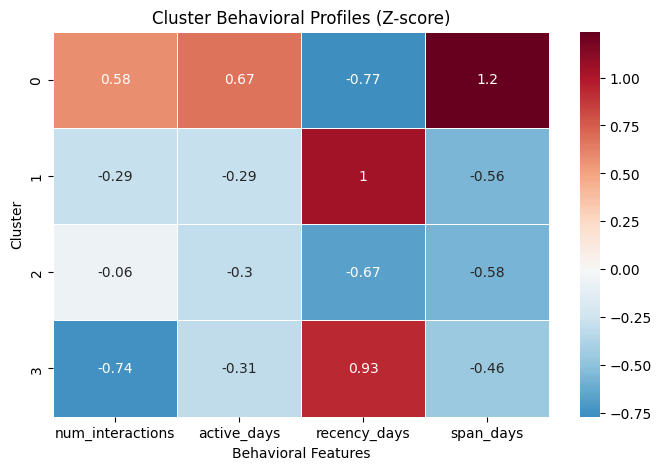

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.heatmap(
    z_profiles,
    annot=True,
    cmap="RdBu_r",
    center=0,
    linewidths=0.5
)

plt.title("Cluster Behavioral Profiles (Z-score)")
plt.xlabel("Behavioral Features")
plt.ylabel("Cluster")
plt.show()

**Temporal Validation** <br>
We earlier used 3 years of latest data to operate on clustering. Now we use the first two years of the three year data and reserve the final year data for validating the cluster trends

1. Firstly gathering relevant data

In [ ]:
import pandas as pd

full_raw_data = pd.read_csv("rating.csv")
full_raw_data['timestamp'] = pd.to_datetime(full_raw_data['timestamp'], format='mixed', errors='coerce')

data_1314 = full_raw_data[(full_raw_data['timestamp'] >= '2013-01-01') & (full_raw_data['timestamp'] <= '2014-12-31')].copy()

df_1314 = (data_1314.groupby("userId").agg(
        num_interactions=("movieId", "count"),
        active_days=("timestamp", lambda x: x.dt.date.nunique()),
        first_interaction=("timestamp", "min"),
        last_interaction=("timestamp", "max")
    )
    .reset_index()
)

ref_date_1314 = pd.Timestamp('2014-12-31')

df_1314["recency_days"] = (ref_date_1314 - df_1314["last_interaction"]).dt.days
df_1314["span_days"] = (df_1314["last_interaction"] - df_1314["first_interaction"]).dt.days

df_1314 = df_1314.drop(columns=["first_interaction", "last_interaction"])

print("Shape of df_1314:", df_1314.shape)
display(df_1314.head())

Shape of df_1314: (620, 5)


,userId,num_interactions,active_days,recency_days,span_days
0,42,51,1,96,0
1,49,30,1,606,0
2,59,25,1,458,0
3,71,45,1,29,0
4,85,69,1,226,0


2. Pre-processing and training the clustering algorithm

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np

# 1. Preprocessing and Log Transformation
df_1314_processed = df_1314.copy()
df_1314_processed["log_num_interactions"] = np.log1p(df_1314_processed["num_interactions"])
df_1314_processed["log_active_days"] = np.log1p(df_1314_processed["active_days"])
df_1314_processed["log_span_days"] = np.log1p(df_1314_processed["span_days"])

# Select features for clustering
X_1314 = df_1314_processed[
    ["log_num_interactions", "log_active_days", "recency_days", "log_span_days"]
]

# 2. Scaling
scaler_1314 = StandardScaler()
X_1314_scaled = scaler_1314.fit_transform(X_1314)

# 3. Clustering (using k=4 as established earlier)
kmeans_1314 = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels_1314 = kmeans_1314.fit_predict(X_1314_scaled)

# 4. Attach labels back to the dataframe
df_1314["cluster"] = cluster_labels_1314

# Display summary of clusters in the 13-14 period
summary_1314 = df_1314.groupby("cluster").agg(
    users=("userId", "count"),
    avg_interactions=("num_interactions", "mean"),
    avg_active_days=("active_days", "mean"),
    avg_recency=("recency_days", "mean"),
    avg_span=("span_days", "mean")
).sort_index()

display(summary_1314)

,users,avg_interactions,avg_active_days,avg_recency,avg_span
cluster,,,,,
0,217,68.179724,1.557604,528.483871,5.359447
1,177,157.056497,27.276836,111.610169,444.542373
2,145,74.165517,1.393103,161.048276,2.365517
3,81,8.864198,2.493827,410.012346,138.444444


3. Validating the last year data next to the trained data

In [ ]:
# 1. Retrieve data for the year 2015
data_2015 = full_raw_data[full_raw_data['timestamp'].dt.year == 2015].copy()

# 2. Count interactions per userId in 2015
interactions_2015 = data_2015.groupby("userId")["movieId"].count().reset_index()
interactions_2015.columns = ["userId", "future_interactions"]

# 3. Merge counts onto df_1314 and fill NaNs with 0
df_1314 = pd.merge(df_1314, interactions_2015, on="userId", how="left")
df_1314["future_interactions"] = df_1314["future_interactions"].fillna(0)

# 4. Create retention column
df_1314["retained_2015"] = df_1314["future_interactions"] > 0

# 5. Compute retention metrics per cluster
retention_analysis = df_1314.groupby("cluster").agg(
    mean_future_interactions=("future_interactions", "mean"),
    retention_rate=("retained_2015", "mean")
).sort_index()

display(retention_analysis)

,mean_future_interactions,retention_rate
cluster,,
0,0.018433,0.004608
1,19.412429,0.502825
2,4.565517,0.075862
3,3.345679,0.111111


4. Verifying the trends that we see in the future interactions with the help of Kruskal Wallis Test

In [ ]:
groups = [
    df_1314[df_1314["cluster"] == c]["future_interactions"]
    for c in sorted(df_1314["cluster"].unique())
]

from scipy.stats import kruskal

stat, p = kruskal(*groups)

print("Kruskal-Wallis H:", stat)
print("p-value:", p)

import numpy as np

N = len(df_1314)
k = df_1314["cluster"].nunique()

eta_sq = (stat - k + 1) / (N - k)

print("Effect size (eta^2):", eta_sq)

Kruskal-Wallis H: 185.3763065555757
p-value: 6.086081607852668e-40
Effect size (eta^2): 0.2960654327200904


In [ ]:
cluster_summary = df_1314.groupby("cluster").agg(
    users=("userId", "count"),
    avg_interactions=("num_interactions", "mean"),
    avg_active_days=("active_days", "mean"),
    avg_recency=("recency_days", "mean"),
    avg_span=("span_days", "mean"),
    mean_future=("future_interactions", "mean"),
    retention=("retained_2015", "mean")
).round(2)

cluster_summary

,users,avg_interactions,avg_active_days,avg_recency,avg_span,mean_future,retention
cluster,,,,,,,
0,217,68.18,1.56,528.48,5.36,0.02,0.00
1,177,157.06,27.28,111.61,444.54,19.41,0.50
2,145,74.17,1.39,161.05,2.37,4.57,0.08
3,81,8.86,2.49,410.01,138.44,3.35,0.11


Thus our validation ends here.

**Now Training a Predictive Model for Future Classifications**

Won't require anything fancier as the data size is relatively smaller. We train a random forest classifier using labels as cluster numbering

In [ ]:
features = ["num_interactions", "active_days", "recency_days", "span_days"]

X = df_1314[features]
y = df_1314["cluster"]

Training the model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

clf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

Interpreting the Results

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9838709677419355
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        44
           1       1.00      0.94      0.97        35
           2       0.94      1.00      0.97        29
           3       1.00      1.00      1.00        16

    accuracy                           0.98       124
   macro avg       0.98      0.99      0.98       124
weighted avg       0.98      0.98      0.98       124



Pretty good accuracy achieved. Let's have a look at what drives it.

In [ ]:
import pandas as pd

importance = pd.Series(
    clf.feature_importances_,
    index=features
).sort_values(ascending=False)

importance

,0
recency_days,0.319792
num_interactions,0.303597
span_days,0.215957
active_days,0.160655


User segments are primarily differentiated by engagement recency and interaction volume, with lifespan duration providing secondary separation. This indicates that platform user behavior follows a lifecycle–intensity structure, where sustained engagement and recent activity define core users, while declining recency and shortened lifespan characterize fading and churned cohorts.

**Experimenting with Gaussian Mixture Models** <br>
Having a look on how it performs on different algorithms

In [ ]:
from sklearn.preprocessing import StandardScaler

features = ["num_interactions", "active_days", "recency_days", "span_days"]

scaler = StandardScaler()
X = scaler.fit_transform(df_1314[features])

In [ ]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)

gmm = GaussianMixture(n_components=4, covariance_type="full", random_state=42)
gmm_labels = gmm.fit_predict(X)

In [ ]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(kmeans_labels, gmm_labels)
print("KMeans vs GMM ARI:", ari)

KMeans vs GMM ARI: 0.2828969038648571


The ARI shows a bit different story, let's have a look at the cluster assignments

In [ ]:
df_gmm = df_1314.copy()
df_gmm["gmm_cluster"] = gmm_labels

gmm_profiles = df_gmm.groupby("gmm_cluster")[features].mean().round(2)
gmm_profiles

,num_interactions,active_days,recency_days,span_days
gmm_cluster,,,,
0,51.36,1.07,388.22,0.00
1,144.41,66.93,7.91,681.45
2,153.73,14.01,155.16,416.25
3,88.10,3.60,366.58,57.64


Thus we can conclude that both KMeans and Gaussian Mixture models recover the same lifecycle-based user segmentation structure consisting of loyal, regular, fading, and churned cohorts, indicating that the identified behavioral segments represent intrinsic data structure rather than algorithm-specific artifacts.